# 11.4.2 结构、耦合与频率锁定

## 学习目标与先修知识

比较两种结构的相位（phase）一致和尾段频率差，限定结论。

先修：11.4.1 序参量（order parameter）与相位方程；11.1.2 规则环与重连；2.4 数值网格。

## 具体问题

同一组单体固有频率在规则环和重连图上耦合时，最终相位是否更集中、平均频率是否更接近？两个判断不同，且有限时间、初相和数值步长会影响曲线。

In [1]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager
from systems_science import plot_style, show_table
plot_style()
font_names = {font.name for font in font_manager.fontManager.ttflist}
for name in ("Microsoft YaHei", "SimHei", "Noto Sans CJK SC"):
    if name in font_names:
        plt.rcParams["font.sans-serif"] = [name, "DejaVu Sans"]
        break
BLUE, PINK, GREEN = "#008bfb", "#ff0051", "#00a56a"

## 初步实验

两个同频振子、相位差 π/2、$K=1$、$h=0.1$ 时，Euler 一步分别向对方靠近 0.1 rad。

In [2]:
print('首步 [0,π/2] → [0.1,π/2−0.1]（无固有频率时）。')

首步 [0,π/2] → [0.1,π/2−0.1]（无固有频率时）。


## 模型假设

12节点、每节点初始4近邻；两结构保持24条边，固有频率集合相同。相位以未取模实数保存，用末尾时间窗的位移计算平均频率；绘图时可取模。耦合按节点度归一化，故比较的是该特定预算定义。有限 $K$ 扫描不构成无限规模同步阈值证明。

## 数学解释与推导

一步显式格式为 $\theta_i^{+}=\theta_i+h[\omega_i+K\sum_jA_{ij}\sin(\theta_j-\theta_i)/\max(1,d_i)]$。尾窗平均频率 $\hat\omega_i=(\theta_i(t_b)-\theta_i(t_a))/(t_b-t_a)$；锁频差可用 $\max_i\hat\omega_i-\min_i\hat\omega_i$ 描述，接近0才说明该窗内频率相近。它与末时刻 $R$ 不可互换。若先把相位取模，跨过 $2\pi$ 的位移会被误读；若步长过大，可能把数值误差（numerical error）当成结构差异。

## 核心实现

下面将本节推导写成可运行函数。

In [3]:
def adjacency(n, edges):
    """Undirected simple graph; edges contain two distinct zero-based node indices."""
    a = [[0] * n for _ in range(n)]
    for i, j in edges:
        a[i][j] = a[j][i] = 1
    return a


def ring_rewire(n, k, probability, seed):
    """Teaching ring rewiring: fixed node/edge count, one endpoint retained."""
    import random
    rng = random.Random(seed)
    original = sorted({tuple(sorted((i, (i + d) % n)))
                       for i in range(n) for d in range(1, k // 2 + 1)})
    edges = set(original)
    for i, j in original:
        if rng.random() >= probability:
            continue
        options = [w for w in range(n) if w != i and tuple(sorted((i, w))) not in edges]
        if options:
            edges.remove((i, j))
            edges.add(tuple(sorted((i, rng.choice(options)))))
    return sorted(edges)


def order_parameter(phases):
    import numpy as np
    return float(abs(np.exp(1j * np.asarray(phases, dtype=float)).mean()))


def phase_step(phases, frequencies, edges, coupling, dt):
    """One explicit network phase step; coupling normalized by node degree."""
    import math
    n = len(phases)
    a = adjacency(n, edges)
    degree = [sum(row) for row in a]
    return [phases[i] + dt * (frequencies[i] + coupling / max(1, degree[i]) *
                             sum(a[i][j] * math.sin(phases[j] - phases[i]) for j in range(n)))
            for i in range(n)]


def phase_run(phases, frequencies, edges, coupling, dt, steps):
    current = list(phases)
    history = [current.copy()]
    for _ in range(steps):
        current = phase_step(current, frequencies, edges, coupling, dt)
        history.append(current)
    return history, [order_parameter(row) for row in history]


def locking_spread(history, dt, tail_steps):
    """Range of per-oscillator mean frequency over the final tail window."""
    last = history[-1]
    before = history[-tail_steps - 1]
    frequencies = [(a - b) / (dt * tail_steps) for a, b in zip(last, before)]
    return max(frequencies) - min(frequencies), frequencies

## 对照实验

同一固有频率集合下，比较规则环与等边数重连图。每个 K 使用8个初相种子；图上同时给末窗 R 与尾窗频率极差的均值和范围。

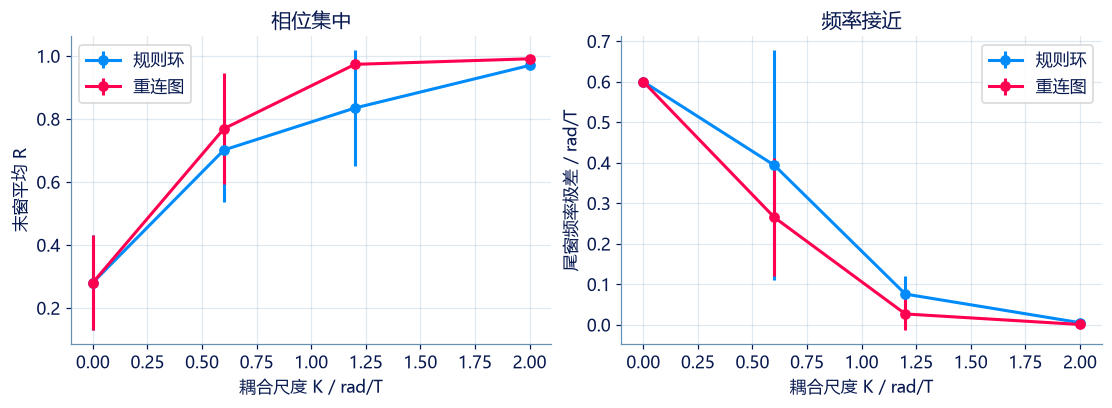

两结构边数 24 24 ；各点初相重复8次。


In [4]:
n=12;ring=ring_rewire(n,4,0.,17);rewired=ring_rewire(n,4,.35,17)
omega=np.linspace(.7,1.3,n).tolist();dt=.04;steps=350;tail=100
conditions={'规则环':ring,'重连图':rewired};scans={}
for name,e in conditions.items():
    rows=[]
    for coupling in [0.,.6,1.2,2.]:
        observations=[]
        for seed in range(8):
            initial=np.random.default_rng(820+seed).uniform(-math.pi,math.pi,n).tolist()
            trace,r_values=phase_run(initial,omega,e,coupling,dt,steps)
            spread,_=locking_spread(trace,dt,tail)
            observations.append((float(np.mean(r_values[-tail:])),spread))
        rows.append(np.array(observations))
    scans[name]=rows
fig,axes=plt.subplots(1,2,figsize=(10,3.6))
for name,rows in scans.items():
    ks=[0.,.6,1.2,2.]
    axes[0].errorbar(ks,[a[:,0].mean() for a in rows],yerr=[a[:,0].std() for a in rows],marker='o',label=name)
    axes[1].errorbar(ks,[a[:,1].mean() for a in rows],yerr=[a[:,1].std() for a in rows],marker='o',label=name)
axes[0].set(xlabel='耦合尺度 K / rad/T',ylabel='末窗平均 R',title='相位集中')
axes[1].set(xlabel='耦合尺度 K / rad/T',ylabel='尾窗频率极差 / rad/T',title='频率接近');axes[0].legend();axes[1].legend();plt.show()
print('两结构边数',len(ring),len(rewired),'；各点初相重复8次。')

## 结果解释

两面板可能呈现不同步调；R 上升不等于所有平均频率已相同。误差棒是这8个初相结果的标准差（standard deviation），不是模型（model）外推置信区间（confidence interval）。重连实现固定为一张；要估计结构生成的波动，还需重复网络。

### 独立核对

手算两振子一步；检查边数、零耦合的末窗频率与固有频率一致，并用半步长核对一组末窗指标。

In [5]:
step=phase_step([0.,math.pi/2],[0.,0.],[[0,1]],1.,.1)
np.testing.assert_allclose(step,[.1,math.pi/2-.1],atol=1e-12)
assert len(ring)==len(rewired)==24
initial=np.linspace(-1,1,n).tolist()
trace,_=phase_run(initial,omega,ring,0.,dt,steps)
_,means=locking_spread(trace,dt,tail)
np.testing.assert_allclose(means,omega,atol=1e-12)
coarse,rc=phase_run(initial,omega,ring,1.2,.04,350)
fine,rf=phase_run(initial,omega,ring,1.2,.02,700)
print('步长.04与.02时末态R：',round(rc[-1],4),round(rf[-1],4))
assert abs(rc[-1]-rf[-1])<.05
print('一步解析、接触预算、零耦合及步长细化检查通过。')

步长.04与.02时末态R： 0.9096 0.9096
一步解析、接触预算、零耦合及步长细化检查通过。


[在本章探索中改变条件](http://127.0.0.1:8000/chapters/11-04-%E8%80%A6%E5%90%88%E6%8C%AF%E5%AD%90%E4%B8%8E%E5%90%8C%E6%AD%A5/explore/)：先预测结果，再比较图形与数值。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：一步网络相位耦合

网络相位（phase）方程 dθ_i/dt=ω_i+[K/max(1,d_i)]∑_j A_ij sin(θ_j−θ_i)。用显式 Euler 走一步；孤立节点只按固有频率前进。返回未取模的相位，供后续频率计算。

**函数与代码模板**

```python
def solve(
    phases: list[float],
    frequencies: list[float],
    edges: list[list[int]],
    coupling: float,
    dt: float,
) -> list[float]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `phases` | `list[float]` | 当前各节点相位。 | rad |
| `frequencies` | `list[float]` | 各节点固有频率。 | rad/T |
| `edges` | `list[list[int]]` | 无向简单耦合边。 | 条 |
| `coupling` | `float` | 各节点总耦合尺度。 | rad/T |
| `dt` | `float` | 正时间步长（time step）。 | T |

**返回值**

直接返回 next_phases（list[float]）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `next_phases` | `list[float]` | 下一步未取模相位。 | rad |

**计算规则**

旧相位同时用于所有节点；节点度为0时耦合和为0。只要求一次题定 Euler 更新，不声称有限 dt 精确。

**约束与边界**

- 只计算题定有限图和数值模型（model）；返回普通 Python 列表、数值或元组。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| phases | 当前各节点相位。 | [0.0, 1.5707963267948966] | rad |
| frequencies | 各节点固有频率。 | [0.0, 0.0] | rad/T |
| edges | 无向简单耦合边。 | [[0, 1]] | 条 |
| coupling | 各节点总耦合尺度。 | 1 | rad/T |
| dt | 正时间步长（time step）。 | 0.1 | T |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
phases = [0.0, 1.5707963267948966]
frequencies = [0.0, 0.0]
edges = [[0, 1]]
coupling = 1.0
dt = 0.1

result = solve(phases, frequencies, edges, coupling, dt)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| next_phases | 下一步未取模相位。 | [0.1, 1.4707963267948965] | rad |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = [0.1, 1.4707963267948965]
```

**样例解释**

首例两个节点分别增减0.1 rad；第三例孤立振子只按自身频率增加0.5 rad。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：一步网络相位耦合](http://127.0.0.1:8000/chapters/11-04-%E8%80%A6%E5%90%88%E6%8C%AF%E5%AD%90%E4%B8%8E%E5%90%8C%E6%AD%A5/practice/?question=p11-one-phase-network-step)

### 第 2 题 · 单项选择题：耦合预算的定义

将每节点耦合项除以 max(1,d_i) 的主要作用是什么？

- **A.** 让不同度节点的总耦合量具有可比尺度；仍需声明拓扑和权重。
- **B.** 保证所有网络完全同步。
- **C.** 把异质固有频率自动消掉。
- **D.** 使图拉普拉斯（graph Laplacian）对任何有向网络都对称。

[作答：耦合预算的定义](http://127.0.0.1:8000/chapters/11-04-%E8%80%A6%E5%90%88%E6%8C%AF%E5%AD%90%E4%B8%8E%E5%90%8C%E6%AD%A5/practice/?question=p11-degree-normalization)

### 第 3 题 · 单项选择题：有限扫描不是通用阈值

某个8节点网络只用一种初相，随 K 增加时 R 突然升高。哪种判断合理？

- **A.** 已证明无限规模普遍临界点。
- **B.** 需检查暂态（transient）、步长、初相、固有频率和规模后再谈模型（model）内转变。
- **C.** R 变化必由代码绘图造成。
- **D.** 所有节点此后频率必锁定。

[作答：有限扫描不是通用阈值](http://127.0.0.1:8000/chapters/11-04-%E8%80%A6%E5%90%88%E6%8C%AF%E5%AD%90%E4%B8%8E%E5%90%8C%E6%AD%A5/practice/?question=p11-finite-scan-threshold)

### 第 4 题 · 单项选择题：比较结构时共用频率

比较环图与增加捷径图的同步过程，应优先固定什么？

- **A.** 相同频率集合、初相分布（distribution）、节点数、耦合定义与时间网格（time grid）。
- **B.** 只固定图的绘制颜色。
- **C.** 给捷径图更大 K 而不说明。
- **D.** 只比较最后一帧截图。

[作答：比较结构时共用频率](http://127.0.0.1:8000/chapters/11-04-%E8%80%A6%E5%90%88%E6%8C%AF%E5%AD%90%E4%B8%8E%E5%90%8C%E6%AD%A5/practice/?question=p11-same-frequencies)

**进一步阅读**

[NetworkX 重连图实现说明](https://networkx.org/documentation/stable/reference/generated/networkx.generators.random_graphs.watts_strogatz_graph.html)提供结构参照；[Kuramoto 与 Battogtokh 的原文](https://arxiv.org/abs/cond-mat/0210694)用于相位模型来源，有限扫描为课程改编。